<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/main/Analysis/DataAnalysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [16]:
# 파일 리스트 (본인의 파일명에 맞게 수정)
file_names = ['P1_AbsoluteThresholdDetection.csv','P2_AbsoluteThresholdDetection.csv','P3_AbsoluteThresholdDetection.csv']
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"no: {file}")

# 데이터 통합
if data_list:
    df = pd.concat(data_list, ignore_index=True)

    # 1. Condition 명칭 변경 (Active -> On-touch)
    df['Condition'] = df['Condition'].replace('Active', 'On-touch (Mid)')
    df = df[df['Condition'] != 'On-touch (Soft)']
    df['Condition'] = df['Condition'].replace('On-touch (Hard)', 'On-touch (Mid)')

    # 2. 분석 대상 구역 필터링 (Area A, B, C)
    df = df[df['Area'].isin(['A', 'B', 'C','D','E','F'])]

    # 3. Force 문자열에서 숫자만 추출 (예: '0.07g' -> 0.07)
    # 문자열 시작 따옴표 앞에 r
    df['Force_Val'] = df['Force'].str.extract(r'(\d+\.?\d*)').astype(float)

    print("완")
else:
    print("없")

완


##Binary based boxplt and scatter

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2231/2968042240.py:9: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


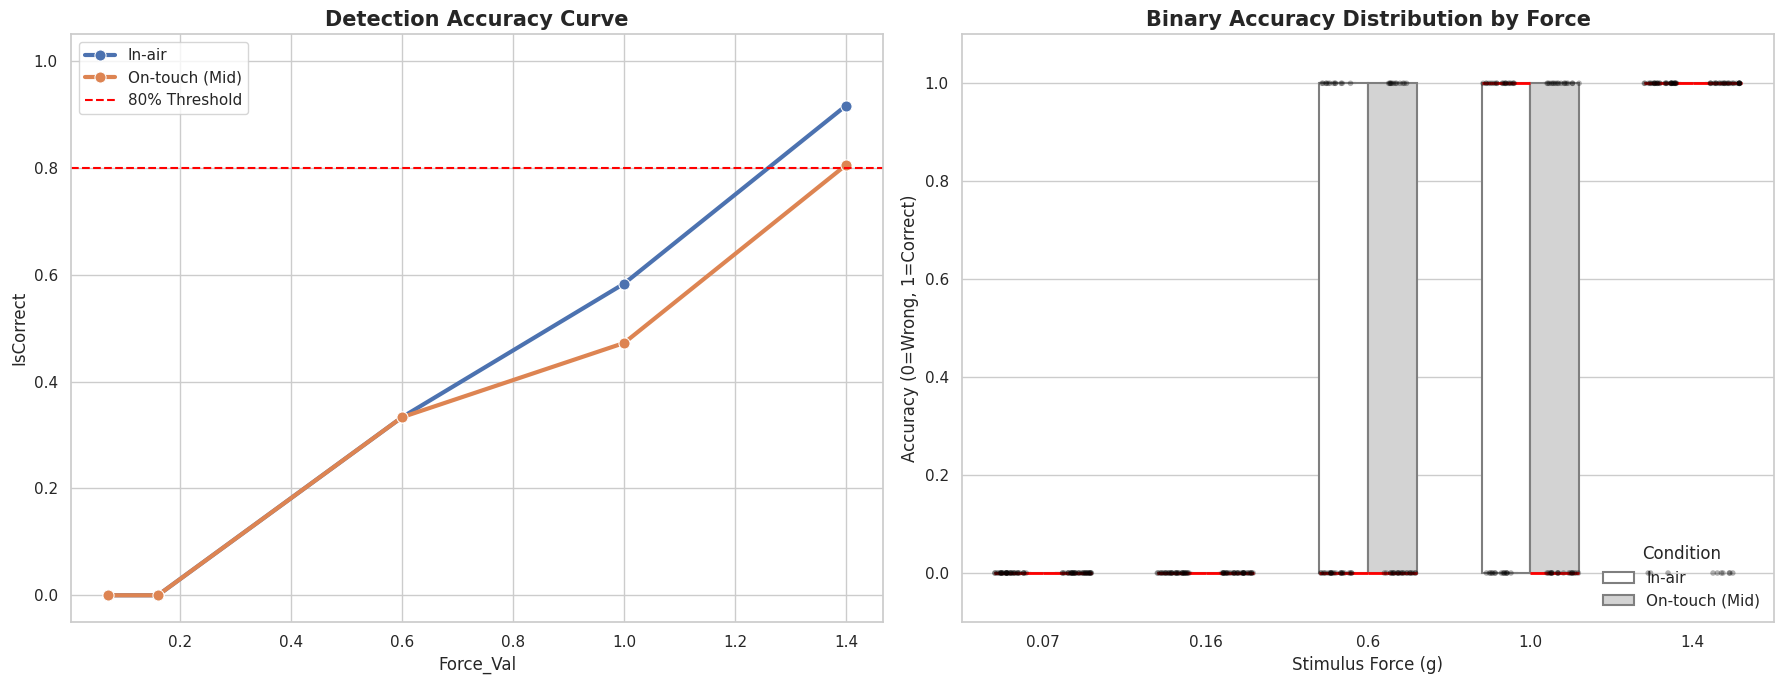

In [17]:
#공백제거
df['Condition'] = df['Condition'].str.strip()

df['Condition'] = df['Condition'].replace('Active', 'On-touch (Mid)')
df['Condition'] = df['Condition'].replace('On-touch (Hard)', 'On-touch (Mid)')

df = df[df['Condition'] != 'On-touch (Soft)']

df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)
force_order = sorted(df['Force_Val'].unique())

# 2. 그래프 그리기 (1x2 Plot)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="white")

# --- (Left) Psychometric Curve (전체 평균) ---
overall_acc = df.groupby(['Condition', 'Force_Val'])['IsCorrect'].mean().reset_index()
sns.lineplot(ax=axes[0], data=overall_acc, x='Force_Val', y='IsCorrect',
             hue='Condition', marker='o', linewidth=3, markersize=8)
axes[0].axhline(0.8, color='red', linestyle='--', label='80% Threshold')
axes[0].set_title('Detection Accuracy Curve', fontsize=15, fontweight='bold')
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend()

# --- (Right) Binary Accuracy Box Plot by Force ---
# y축이 IsCorrect(0 또는 1)인 상태에서 강도별 분포 확인
sns.boxplot(
    ax=axes[1], data=df, x='Force_Val', y='IsCorrect', hue='Condition',
    order=force_order, palette=['#FFFFFF', '#D3D3D3'],
    linewidth=1.5, fliersize=0, width=0.6,
    medianprops={'color': 'red', 'linewidth': 2}  # 중앙값 빨간 선
)

# 개별 응답(0 또는 1)을 점으로 표시
sns.stripplot(
    ax=axes[1], data=df, x='Force_Val', y='IsCorrect', hue='Condition',
    order=force_order, dodge=True, palette=['#000000', '#000000'],
    alpha=0.3, size=4, jitter=0.2
)

axes[1].set_title('Binary Accuracy Distribution by Force', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Stimulus Force (g)', fontsize=12)
axes[1].set_ylabel('Accuracy (0=Wrong, 1=Correct)', fontsize=12)
axes[1].set_ylim(-0.1, 1.1)

# 레전드 정리
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')

plt.tight_layout()
plt.show()

In [18]:
# [추가] overall_acc 정의: 구역(Area)에 상관없이 조건/강도별 전체 평균 정답률 계산
overall_acc = df.groupby(['Condition', 'Force_Val'])['IsCorrect'].mean().reset_index()

# [추가] area_acc 정의: (혹시 안 되어 있을 경우를 대비) 구역별 정답률
area_acc = df.groupby(['Condition', 'Area'])['IsCorrect'].mean().reset_index()

print("="*40)
print("       [SUMMARY STATISTICS]       ")
print("="*40)

# 역치 산출 (정답률 80% 기준 최소 강도)
print("\n1. Estimated Absolute Thresholds (80% Accuracy):")
for cond in overall_acc['Condition'].unique():
    cond_df = overall_acc[overall_acc['Condition'] == cond]
    threshold_df = cond_df[cond_df['IsCorrect'] >= 0.8]

    if not threshold_df.empty:
        threshold = threshold_df['Force_Val'].min()
        print(f" - {cond}: {threshold}g")
    else:
        print(f" - {cond}: 80% 정답률에 도달하지 못함")

# 구역별 상세 정답률 출력
print("\n2. Regional Accuracy Table:")
pivot_area = area_acc.pivot(index='Area', columns='Condition', values='IsCorrect')
print(pivot_area)

# 강도별 상세 정답률 출력
print("\n3. Force-wise Accuracy Table:")
pivot_force = overall_acc.pivot(index='Force_Val', columns='Condition', values='IsCorrect')
print(pivot_force)

       [SUMMARY STATISTICS]       

1. Estimated Absolute Thresholds (80% Accuracy):
 - In-air: 1.4g
 - On-touch (Mid): 1.4g

2. Regional Accuracy Table:
Condition    In-air  On-touch (Mid)
Area                               
A          0.433333        0.300000
B          0.433333        0.533333
C          0.533333        0.300000
D          0.200000        0.333333
E          0.300000        0.233333
F          0.300000        0.233333

3. Force-wise Accuracy Table:
Condition    In-air  On-touch (Mid)
Force_Val                          
0.07       0.000000        0.000000
0.16       0.000000        0.000000
0.60       0.333333        0.333333
1.00       0.583333        0.472222
1.40       0.916667        0.805556


##relative accuracy || error based score

In [19]:
for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"no: {file}")

# 데이터 통합
if data_list:
    df = pd.concat(data_list, ignore_index=True)

    # 1. Condition 명칭 변경 (Active -> On-touch)
    df['Condition'] = df['Condition'].str.strip()

    df['Condition'] = df['Condition'].replace('Active', 'On-touch (Mid)')
    df['Condition'] = df['Condition'].replace('On-touch (Hard)', 'On-touch (Mid)')

    df = df[df['Condition'] != 'On-touch (Soft)']

    # 2. 분석 대상 구역 필터링 (Area A, B, C)
    df = df[df['Area'].isin(['A', 'B', 'C','D','E','F'])]

    # 3. Force 문자열에서 숫자만 추출 (예: '0.07g' -> 0.07)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)

    print("완")
else:
    print("없")

완


<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2231/3748601826.py:24: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


##Relative Accuracy | Target이 분모

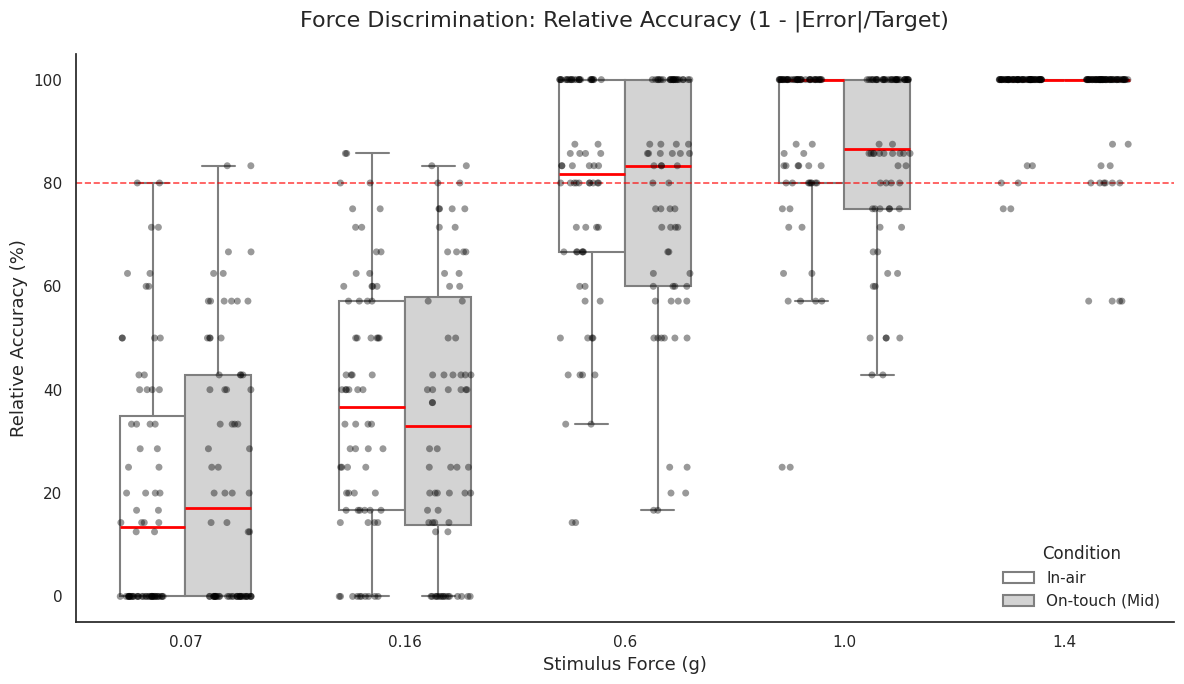

In [20]:
# 2. 새로운 Relative Accuracy 계산 (Target 대비 오차 비율 반영)
def calc_relative_accuracy(row):
    # Target이 0인 경우(분모가 0이 되는 경우) 방지
    if row['Target'] == 0:
        return 100 if row['Response'] == 0 else 0

    # Target 대비 절대 오차 비율 계산: |Target - Response| / Target
    error_ratio = abs(row['Target'] - row['Response']) / row['Target']

    # 정확도 계산: (1 - 오차비율) * 100
    score = (1 - error_ratio) * 100

    # 점수가 음수가 되지 않도록 하한선(0) 적용
    return max(0, score)

df['Relative_Score'] = df.apply(calc_relative_accuracy, axis=1)

# 3. 시각화 (동일한 스타일 유지)
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")
force_order = sorted(df['Force_Val'].unique())

ax = sns.boxplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    palette=['#FFFFFF', '#D3D3D3'],
    linewidth=1.5, fliersize=0, width=0.6, order=force_order,
    medianprops={'color': 'red', 'linewidth': 2}
)

sns.stripplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    dodge=True, palette=['#000000', '#000000'],
    alpha=0.4, size=5, jitter=0.2, ax=ax, order=force_order
)

# 80% 성능 가이드라인
plt.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

plt.title('Absolute Threshold Detection: Relative Accuracy (1 - |Error|/Target)', fontsize=16, pad=20)
plt.xlabel('Stimulus Force (g)', fontsize=13)
plt.ylabel('Relative Accuracy (%)', fontsize=13)
plt.ylim(-5, 105)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

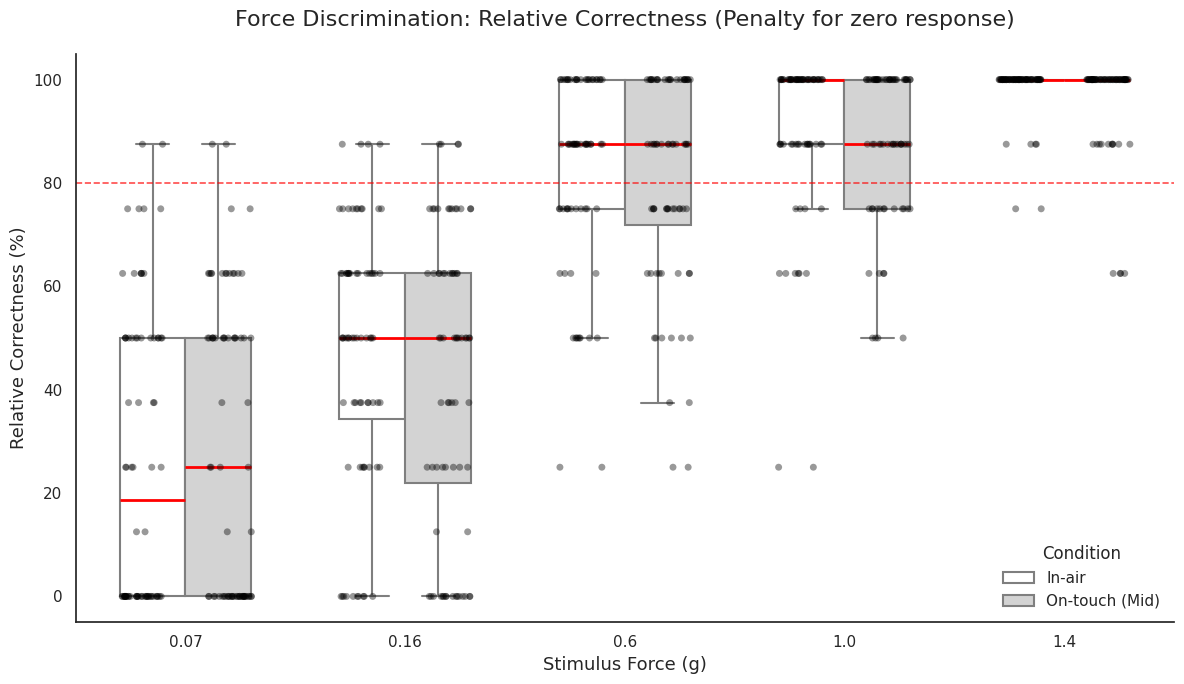

In [21]:
# 2. 수정된 Relative Score 계산 (응답 0일 경우 무조건 0점)
def calc_relative_score(row):
    # 피험자가 0번이라고 답한 경우 (인지 실패) -> 무조건 0점
    if row['Response'] == 0:
        return 0

    # 그 외의 경우: 오차 1회당 10점씩 감점 (최소 0점)
    error = abs(row['Target'] - row['Response'])
    score = 100 - (error * 12.5)
    return max(0, score)

df['Relative_Score'] = df.apply(calc_relative_score, axis=1)

# 3. 시각화
plt.figure(figsize=(12, 7))
sns.set_theme(style="white")
force_order = sorted(df['Force_Val'].unique())

ax = sns.boxplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    palette=['#FFFFFF', '#D3D3D3'],
    linewidth=1.5, fliersize=0, width=0.6, order=force_order,
    medianprops={'color': 'red', 'linewidth': 2}
)

sns.stripplot(
    data=df, x='Force_Val', y='Relative_Score', hue='Condition',
    dodge=True, palette=['#000000', '#000000'],
    alpha=0.4, size=5, jitter=0.2, ax=ax, order=force_order
)

plt.axhline(80, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
plt.title('Force Discrimination: Relative Correctness (Penalty for zero response)', fontsize=16, pad=20)
plt.xlabel('Stimulus Force (g)', fontsize=13)
plt.ylabel('Relative Correctness (%)', fontsize=13)
plt.ylim(-5, 105)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[0:2], labels[0:2], title='Condition', frameon=False, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

##Region별 accuracy

In [22]:
# 1. 파일 리스트 (본인의 CSV 파일명으로 수정)
file_names = ['P1_AbsoluteThresholdDetection.csv','P2_AbsoluteThresholdDetection.csv']
df_list = []

for f in file_names:
    try:
        temp = pd.read_csv(f)
        df_list.append(temp)
    except FileNotFoundError:
        print(f"⚠️ 파일을 찾을 수 없음: {f}")

# 2. 데이터 통합 및 클리닝
df['Condition'] = df['Condition'].str.strip()

df['Condition'] = df['Condition'].replace('Active', 'On-touch (Mid)')
df['Condition'] = df['Condition'].replace('On-touch (Hard)', 'On-touch (Mid)')

df = df[df['Condition'] != 'On-touch (Soft)']

df = df[df['Area'].isin(['A', 'B', 'C','D','E','F'])]
# '0.07g' 문자열에서 숫자만 추출
df['Force_Val'] = df['Force'].str.extract(r'(\d+\.?\d*)').astype(float)

# 3. 구역별/강도별 정답률 계산 (Dilution 방지 핵심)
region_acc = df.groupby(['Condition', 'Area', 'Force_Val'])['IsCorrect'].mean().reset_index()

print("✅ 데이터 전처리 및 Region별 그룹화 완료")

✅ 데이터 전처리 및 Region별 그룹화 완료


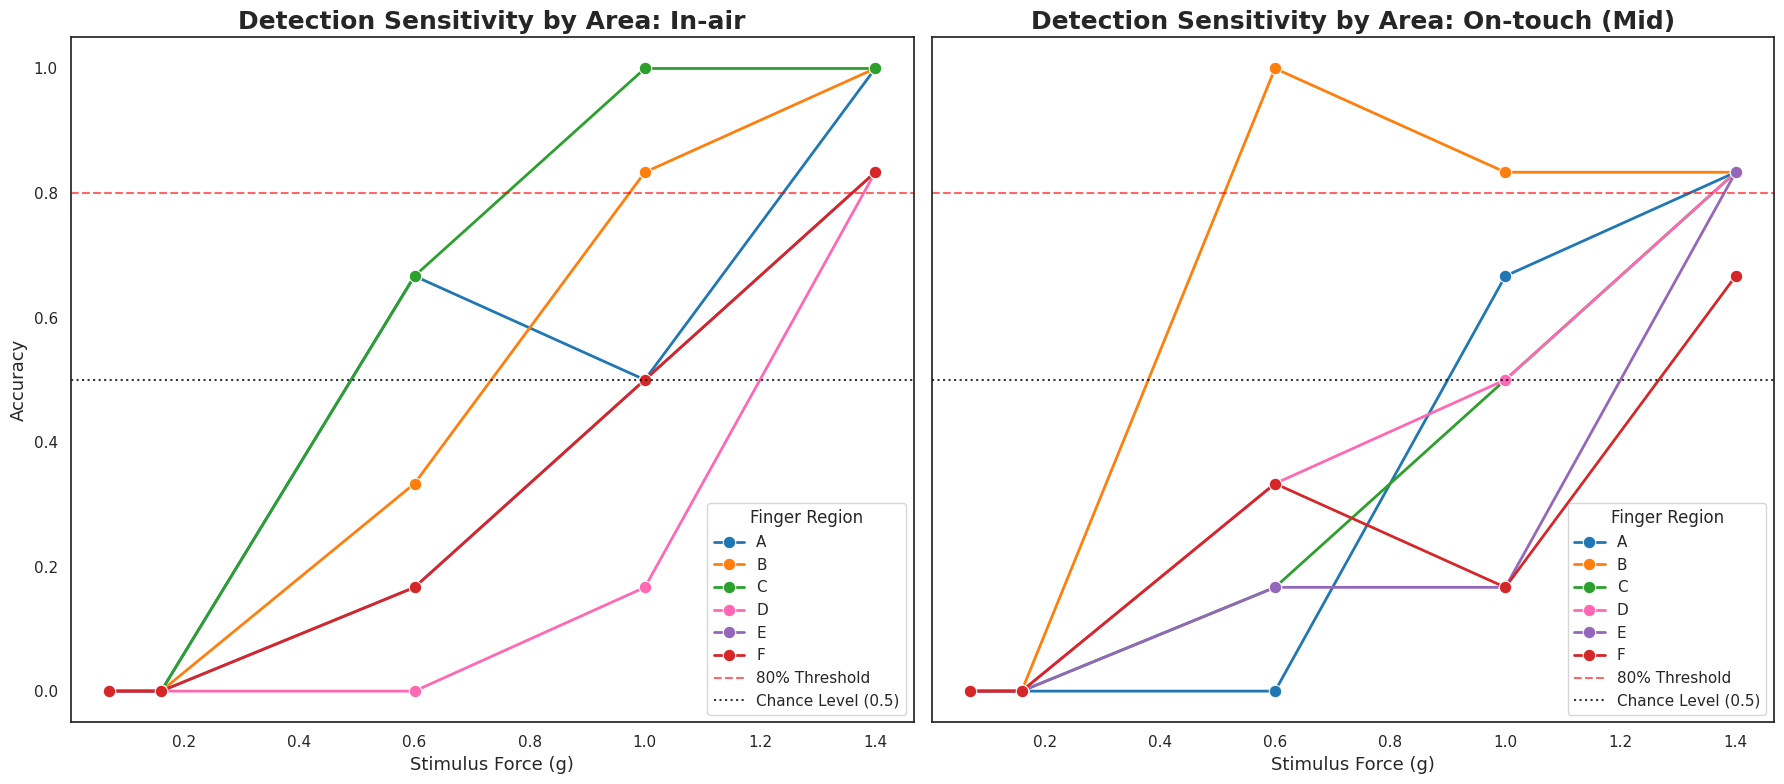

In [23]:
# In-air와 On-touch를 비교하기 위한 1x2 서브플롯
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

conditions = ['In-air', 'On-touch (Mid)']
# 구역별 색상 고정 (A: 청색, B: 황색, C: 녹색, D:핑크)
colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c", "D": "#FF69B4","E" : "#9467bd", "F": "#d62728"}


for i, cond in enumerate(conditions):
    cond_data = region_acc[region_acc['Condition'] == cond]

    # Area별로 선을 따로 그림
    sns.lineplot(
        ax=axes[i],
        data=cond_data,
        x='Force_Val',
        y='IsCorrect',
        hue='Area',
        hue_order=['A', 'B', 'C','D','E','F'],
        palette=colors,
        marker='o',
        linewidth=2,
        markersize=9
    )

    # 기준선 추가 (80% 역치 및 50% 찍기 수준)
    axes[i].axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80% Threshold')
    axes[i].axhline(0.5, color='black', linestyle=':', alpha=0.8, label='Chance Level (0.5)')

    axes[i].set_title(f'Detection Sensitivity by Area: {cond}', fontsize=18, fontweight='bold')
    axes[i].set_xlabel('Stimulus Force (g)', fontsize=13)
    axes[i].set_ylabel('Accuracy', fontsize=13)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(title="Finger Region", fontsize=11)

plt.tight_layout()
plt.show()

##Box Plot for Region

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2231/2973596060.py:22: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


발견된 파일: ['P1_AbsoluteThresholdDetection.csv', 'P3_AbsoluteThresholdDetection.csv', 'P2_AbsoluteThresholdDetection.csv']


/tmp/ipykernel_2231/2973596060.py:69: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipykernel_2231/2973596060.py:69: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


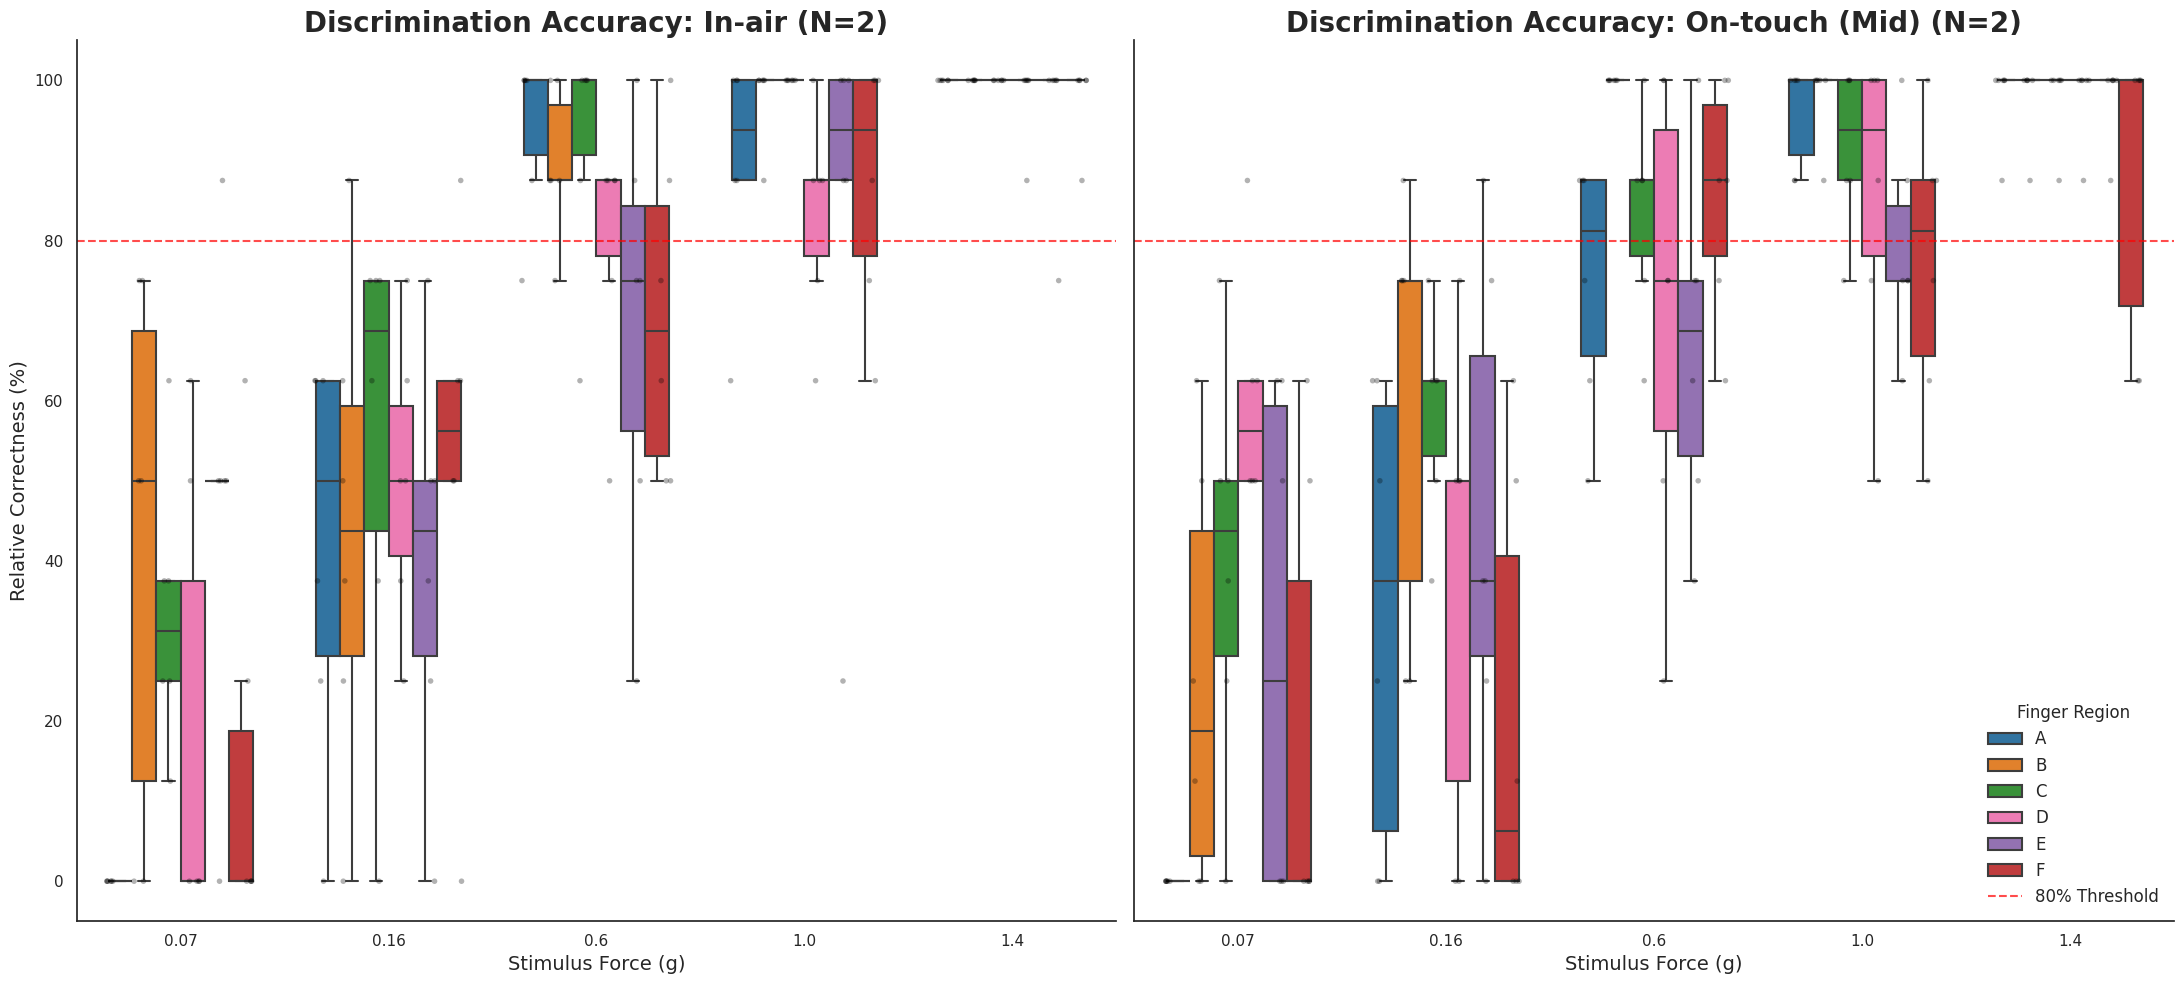

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. 모든 Tactile_S*.csv 파일 자동 로드 및 통합
file_pattern = 'P*_AbsoluteThresholdDetection.csv'
#file_names = ['P1_AbsoluteThresholdDetection']
all_files = glob.glob(file_pattern)

if not all_files:
    print("분석할 CSV 파일을 찾을 수 없습니다.")
else:
    print(f"발견된 파일: {all_files}")
    df_list = [pd.read_csv(f) for f in all_files]
    df = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리
    # Force 값 추출 (예: '0.6g' -> 0.6)
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)
    # Condition 명칭 통일
    df['Condition'] = df['Condition'].str.strip()

    df['Condition'] = df['Condition'].replace('Active', 'On-touch (Mid)')
    df['Condition'] = df['Condition'].replace('On-touch (Hard)', 'On-touch (Mid)')

    df = df[df['Condition'] != 'On-touch (Soft)']

    # 3. 12.5% 페널티 로직 적용 (최대 8회 기준, 응답 0이면 0점)
    def calc_relative_score(row):
        if row['Response'] == 0:
            return 0
        error = abs(row['Target'] - row['Response'])
        # 최대 8회 기준: 100 / 8 = 12.5% 페널티
        score = 100 - (error * 12.5)
        return max(0, score)

    df['Relative_Score'] = df.apply(calc_relative_score, axis=1)

    # 4. 시각화 (1x2 Subplots: In-air vs On-touch)
    fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
    sns.set_theme(style="white")

    conditions = ['In-air', 'On-touch (Mid)']
    colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c", "D": "#FF69B4","E" : "#9467bd", "F": "#d62728"}
    force_order = sorted(df['Force_Val'].unique())

    for i, cond in enumerate(conditions):
        cond_data = df[df['Condition'] == cond]

        # Box Plot: x축은 Force, hue는 Area
        sns.boxplot(
            ax=axes[i],
            data=cond_data,
            x='Force_Val',
            y='Relative_Score',
            hue='Area',
            hue_order=['A', 'B', 'C','D','E','F'],
            palette=colors,
            width=0.7,
            linewidth=1.5,
            fliersize=0,
            order=force_order
        )

        # Scatter Point (Strip plot) 겹치기 (개별 피험자 데이터 점)
        sns.stripplot(
            ax=axes[i],
            data=cond_data,
            x='Force_Val',
            y='Relative_Score',
            hue='Area',
            hue_order=['A', 'B', 'C','D','E','F'],
            dodge=True,
            palette=['#000000']*3, # 시인성을 위해 검은색 점 사용
            alpha=0.3,
            size=4,
            jitter=0.15,
            order=force_order,
            legend=False
        )

        # 80% 역치 기준선
        axes[i].axhline(80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Threshold')

        # 타이틀 및 라벨 설정 (N수 자동 표시)
        num_subjects = df['SubjectID'].nunique()
        axes[i].set_title(f'Discrimination Accuracy: {cond} (N={num_subjects})', fontsize=20, fontweight='bold')
        axes[i].set_xlabel('Stimulus Force (g)', fontsize=14)
        axes[i].set_ylabel('Relative Correctness (%)' if i==0 else "", fontsize=14)
        axes[i].set_ylim(-5, 105)

        # 레전드 설정
        if i == 1:
            axes[i].legend(title="Finger Region", loc='lower right', frameon=False, fontsize=12)
        else:
            if axes[i].get_legend():
                axes[i].get_legend().remove()

    sns.despine()
    plt.tight_layout()
    plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2231/3731848131.py:21: SyntaxWarning: invalid escape sequence '\d'
  df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)


발견된 파일: ['P1_AbsoluteThresholdDetection.csv', 'P3_AbsoluteThresholdDetection.csv', 'P2_AbsoluteThresholdDetection.csv']


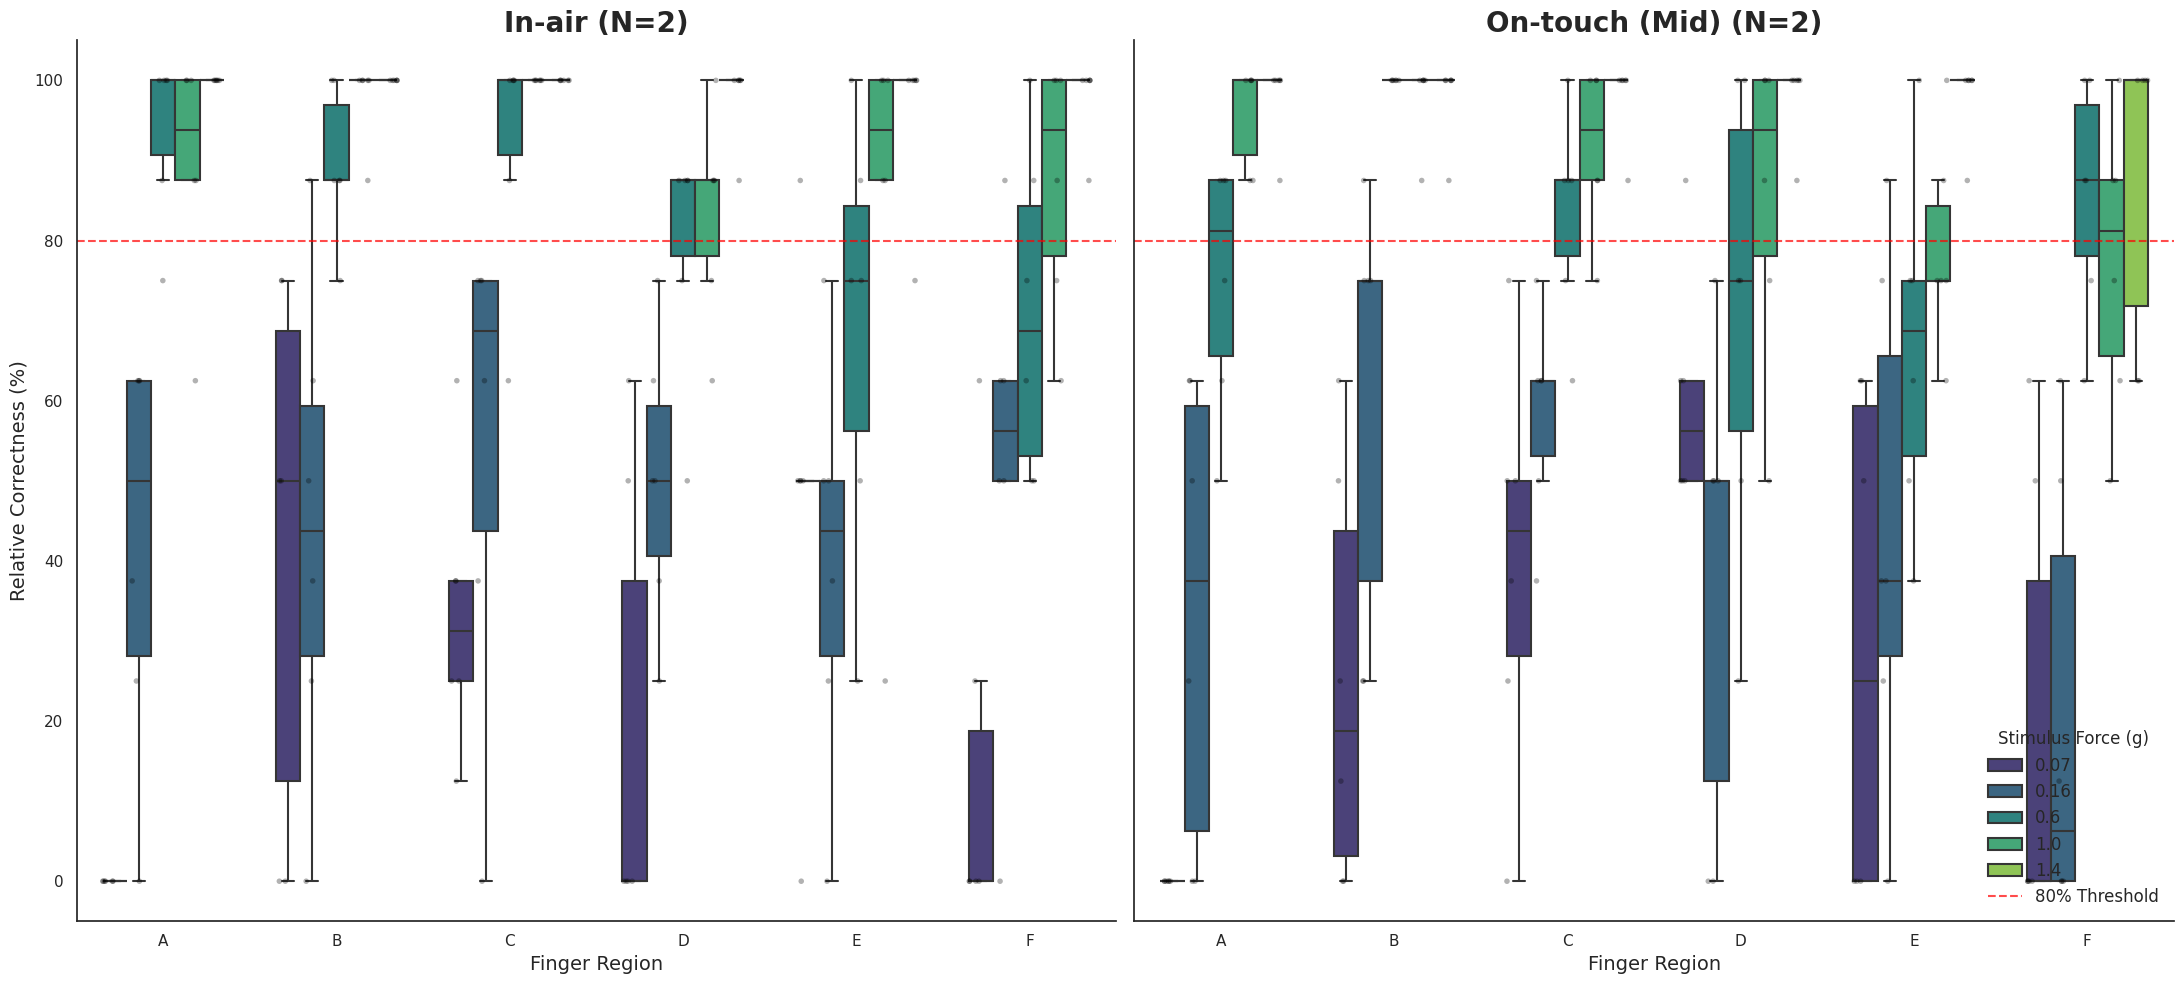

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. 모든 AbsoluteThresholdDetection.csv 파일 자동 로드 및 통합
file_pattern = 'P*_AbsoluteThresholdDetection.csv'
all_files = glob.glob(file_pattern)

if not all_files:
    print("분석할 CSV 파일을 찾을 수 없습니다.")
else:
    print(f"발견된 파일: {all_files}")
    df_list = [pd.read_csv(f) for f in all_files]
    df = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리
    # Force 값 추출
    df['Force_Val'] = df['Force'].str.extract('(\d+\.?\d*)').astype(float)
    # Condition 명칭 정리
    df['Condition'] = df['Condition'].str.strip()
    df['Condition'] = df['Condition'].replace({'Active': 'On-touch (Mid)', 'On-touch (Hard)': 'On-touch (Mid)'})
    df = df[df['Condition'] != 'On-touch (Soft)']

    # 3. 페널티 로직 (기존 유지)
    def calc_relative_score(row):
        if row['Response'] == 0: return 0
        error = abs(row['Target'] - row['Response'])
        score = 100 - (error * 12.5)
        return max(0, score)

    df['Relative_Score'] = df.apply(calc_relative_score, axis=1)

    # 4. 시각화 (X축: Area, Hue: Force)
    fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
    sns.set_theme(style="white")

    conditions = ['In-air', 'On-touch (Mid)']
    # 강도별 색상을 시각적으로 구분하기 좋은 팔레트 설정 (강도가 높을수록 진해지게 설정 가능)
    force_order = sorted(df['Force_Val'].unique())
    area_order = ['A', 'B', 'C', 'D','E','F']

    # 강도 종류 수에 맞게 컬러맵 생성
    palette_force = sns.color_palette("viridis", len(force_order))

    for i, cond in enumerate(conditions):
        cond_data = df[df['Condition'] == cond]

        # Box Plot: x축은 Area, hue는 Force_Val
        sns.boxplot(
            ax=axes[i],
            data=cond_data,
            x='Area',
            y='Relative_Score',
            hue='Force_Val',
            order=area_order,
            hue_order=force_order,
            palette=palette_force,
            width=0.7,
            linewidth=1.5,
            fliersize=0
        )

        # Scatter Point (Strip plot) 겹치기
        sns.stripplot(
            ax=axes[i],
            data=cond_data,
            x='Area',
            y='Relative_Score',
            hue='Force_Val',
            order=area_order,
            hue_order=force_order,
            dodge=True,           # Box 위치에 맞춰 점 분산
            palette=['#000000'] * len(force_order), # 검은색 점
            alpha=0.3,
            size=4,
            jitter=0.15,
            legend=False
        )

        # 80% 역치 기준선
        axes[i].axhline(80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Threshold')

        # 타이틀 및 라벨 설정
        num_subjects = df['SubjectID'].nunique()
        axes[i].set_title(f'{cond} (N={num_subjects})', fontsize=20, fontweight='bold')
        axes[i].set_xlabel('Finger Region', fontsize=14)
        axes[i].set_ylabel('Relative Correctness (%)' if i==0 else "", fontsize=14)
        axes[i].set_ylim(-5, 105)

        # 레전드 설정
        if i == 1:
            axes[i].legend(title="Stimulus Force (g)", loc='lower right', frameon=False, fontsize=12)
        else:
            if axes[i].get_legend():
                axes[i].get_legend().remove()

    sns.despine()
    plt.tight_layout()
    plt.show()

In [26]:
print("="*50)
print(" [각 조건/구역별 80% 정답률 도달 Force (g)] ")
print("="*50)

# 정답률이 0.8 이상인 데이터 중 가장 작은 Force 값을 찾음
thresholds = region_acc[region_acc['IsCorrect'] >= 0.8].groupby(['Condition', 'Area'])['Force_Val'].min().reset_index()

# 보기 좋게 피벗 테이블로 출력
pivot_thresholds = thresholds.pivot(index='Area', columns='Condition', values='Force_Val')
print(pivot_thresholds)

print("\n💡 해석 팁: 값이 작을수록 더 낮은 힘에서 자극을 감지했다는 뜻임.")

 [각 조건/구역별 80% 정답률 도달 Force (g)] 
Condition  In-air  On-touch (Mid)
Area                             
A             1.4             1.4
B             1.0             0.6
C             1.0             1.4
D             1.4             1.4
E             1.4             1.4
F             1.4             NaN

💡 해석 팁: 값이 작을수록 더 낮은 힘에서 자극을 감지했다는 뜻임.


In [27]:
# 각 조건/구역별로 정확히 80%를 넘는 최소 Force 값을 찾는 코드
thresholds = region_acc[region_acc['IsCorrect'] >= 0.8].groupby(['Condition', 'Area'])['Force_Val'].min()
print(thresholds)

Condition       Area
In-air          A       1.4
                B       1.0
                C       1.0
                D       1.4
                E       1.4
                F       1.4
On-touch (Mid)  A       1.4
                B       0.6
                C       1.4
                D       1.4
                E       1.4
Name: Force_Val, dtype: float64


발견된 파일: ['P1_AbsoluteThresholdDetection.csv', 'P3_AbsoluteThresholdDetection.csv', 'P2_AbsoluteThresholdDetection.csv']


/tmp/ipykernel_2231/1190819457.py:73: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(
/tmp/ipykernel_2231/1190819457.py:73: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(


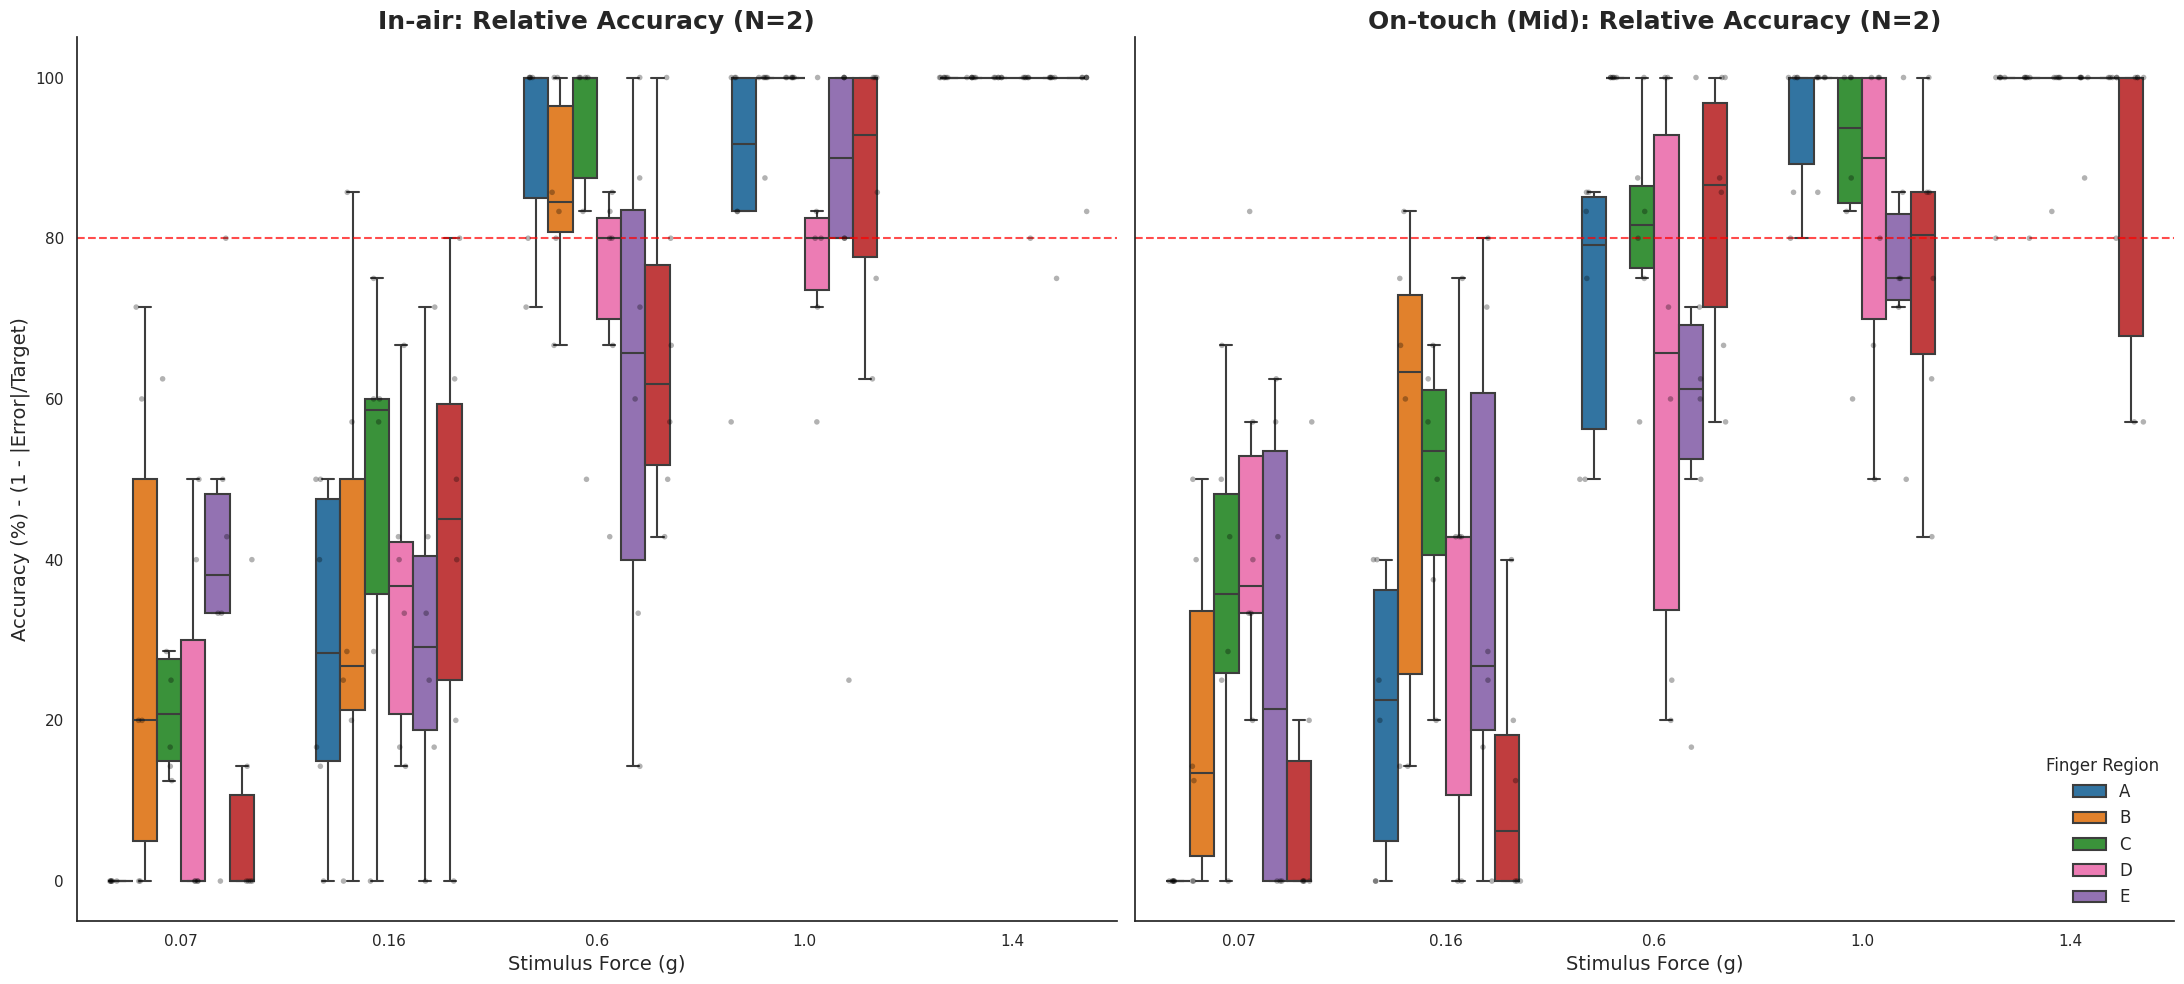


 [Condition/Area별 평균 정확도(Relative Accuracy %)] 
Area                    A          B          C          D          E  \
Condition                                                               
In-air          61.539683  69.702381  72.452381  59.809524  61.845238   
On-touch (Mid)  56.682540  73.202381  70.134921  64.376984  59.396825   

Area                    F  
Condition                  
In-air          60.333333  
On-touch (Mid)  53.757937  


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# 1. 모든 AbsoluteThresholdDetection.csv 파일 자동 로드 및 통합
file_pattern = 'P*_AbsoluteThresholdDetection.csv'
all_files = glob.glob(file_pattern)

if not all_files:
    print("분석할 CSV 파일을 찾을 수 없습니다. 파일명을 확인해주세요.")
else:
    print(f"발견된 파일: {all_files}")
    df_list = [pd.read_csv(f) for f in all_files]
    df = pd.concat(df_list, ignore_index=True)

    # 2. 데이터 전처리
    # Force 값 추출 (예: '0.6g' -> 0.6)
    df['Force_Val'] = df['Force'].str.extract(r'(\d+\.?\d*)').astype(float)

    # [수정된 부분] 3. 새로운 Relative Accuracy 계산 (Target 대비 오차 비율 반영)
    def calc_relative_accuracy(row):
        # Target이 0인 경우(분모가 0) 방지
        if row['Target'] == 0:
            return 100 if row['Response'] == 0 else 0

        # Target 대비 절대 오차 비율 계산: |Target - Response| / Target
        error_ratio = abs(row['Target'] - row['Response']) / row['Target']

        # 정확도 계산: (1 - 오차비율) * 100
        score = (1 - error_ratio) * 100

        # 점수가 음수가 되지 않도록 하한선(0) 적용
        return max(0, score)

    df['Relative_Score'] = df.apply(calc_relative_accuracy, axis=1)

    # 4. 시각화 (1x2 Subplots: In-air vs On-touch)
    fig, axes = plt.subplots(1, 2, figsize=(22, 10), sharey=True)
    sns.set_theme(style="white")

    conditions = ['In-air', 'On-touch (Mid)']
    # 구역별 색상 설정 (D 구역 핑크 유지)
    colors = {"A": "#1f77b4", "B": "#ff7f0e", "C": "#2ca02c", "D": "#FF69B4","E" : "#9467bd", "F": "#d62728"}
    force_order = sorted(df['Force_Val'].unique())

    for i, cond in enumerate(conditions):
        cond_data = df[df['Condition'] == cond]

        # 만약 데이터가 비어있다면 skip
        if cond_data.empty:
            axes[i].set_title(f'No data for {cond}')
            continue

        # Box Plot: x축은 Force, hue는 Area
        sns.boxplot(
            ax=axes[i],
            data=cond_data,
            x='Force_Val',
            y='Relative_Score',
            hue='Area',
            hue_order=['A', 'B', 'C', 'D','E','F'],
            palette=colors,
            width=0.7,
            linewidth=1.5,
            fliersize=0,
            order=force_order
        )

        # Scatter Point (Strip plot) 겹치기
        sns.stripplot(
            ax=axes[i],
            data=cond_data,
            x='Force_Val',
            y='Relative_Score',
            hue='Area',
            hue_order=['A', 'B', 'C', 'D','E','F'],
            dodge=True,
            palette=['#000000']*4, # 시인성을 위해 검은색 점 사용
            alpha=0.3,
            size=4,
            jitter=0.15,
            order=force_order,
            legend=False
        )

        # 80% 역치 기준선 (정확도 가이드라인)
        axes[i].axhline(80, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Threshold')

        # 타이틀 및 라벨 설정
        num_subjects = df['SubjectID'].nunique()
        axes[i].set_title(f'{cond}: Relative Accuracy (N={num_subjects})', fontsize=18, fontweight='bold')
        axes[i].set_xlabel('Stimulus Force (g)', fontsize=14)
        axes[i].set_ylabel('Accuracy (%) - (1 - |Error|/Target)' if i==0 else "", fontsize=14)
        axes[i].set_ylim(-5, 105)

        # 레전드 설정 (두 번째 플롯에만 표시)
        if i == 1:
            handles, labels = axes[i].get_legend_handles_labels()
            # Boxplot 핸들만 추출 (첫 4개 Area + 1개 Threshold 선)
            axes[i].legend(handles[0:5], labels[0:5], title="Finger Region", loc='lower right', frameon=False, fontsize=12)
        else:
            if axes[i].get_legend():
                axes[i].get_legend().remove()

    sns.despine()
    plt.tight_layout()
    plt.show()

    # 간단한 요약 통계 출력
    print("\n" + "="*50)
    print(" [Condition/Area별 평균 정확도(Relative Accuracy %)] ")
    print("="*50)
    summary = df.groupby(['Condition', 'Area'])['Relative_Score'].mean().unstack()
    print(summary)